# 从零搭建LLM
## LLaMA2
模型结构图如下：
![alt text](LLama2.png)
### 超参定义
包括模型的大小、层数、头数、词嵌入维度、隐藏层维度等，通过定义ModelConfig类来存储，继承自transformers库中的PretrainedConfig

In [35]:
from transformers import PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutputWithPast
from typing import Tuple, Optional

class ModelConfig(PretrainedConfig):
    model_type = "Tiny-K"
    def __init__(
        self,
        dim: int = 768, # 模型维度
        n_layers: int = 12,
        n_heads: int = 16,
        n_kv_heads: int = 8,
        vocab_size: int = 6144,
        hidden_dim: int = None,
        multiple_of: int = 64,
        norm_eps: float = 1e-5,
        max_seq_len: int = 512,
        dropout: float = 0.0,
        flash_attn: bool = True,
        **kwargs,
    ):
        self.dim = dim
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.multiple_of = multiple_of
        self.norm_eps = norm_eps
        self.max_seq_len = max_seq_len
        self.dropout = dropout
        self.flash_attn = flash_attn
        super().__init__(**kwargs)

### 构建RMSNorm
$$RMSNorm(x)=\frac{x}{\sqrt{\frac{1}{n}\sum_{i=1}^n x_i^2+\epsilon}}\gamma$$
其中，$x_i$是输入向量的第i个元素，n是输入向量的维度，$\gamma是可学习的缩放参数，对应self.weight$

有助于确保权重规模不会过大或过小

In [9]:
import torch
from torch import nn
import torch.nn.functional as F

class RMSNorm(nn.Module):
    def __init__(self, dim:int, eps:float):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        res = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return res

    def forward(self, x):
        output = self._norm(x.float()).type_as(x)
        return output * self.weight
        

### 构建LLaMA2 Attention
我们选择分组查询注意力机制GQA，可以提高模型效率，节省显存占用。

#### repeat_kv

In [10]:
def repeat_kv(x: torch.Tensor, n_rep: int) -> torch.Tensor:
    # 获取输入张量的形状：批量大小、序列长度、键/值对头的数量、每个头的维度大小
    bs, slen, n_kv_heads, head_dim = x.shape
    
    # 如果重复次数为1，则不需要重复，直接返回原始张量
    if n_rep == 1:
        return x
    
    # 对张量进行扩展和重塑操作以重复键值对
    return (
        x[:, :, :, None, :]  # 在第四个维度（头的维度前）添加一个新的维度
        .expand(bs, slen, n_kv_heads, n_rep, head_dim)  # 将新添加的维度扩展到n_rep大小，实现重复的效果
        .reshape(bs, slen, n_kv_heads * n_rep, head_dim)  # 重新塑形，合并键/值对头的数量和重复次数的维度
    )


#### 旋转嵌入（RoPE）
LLaMA2 模型中的一个重要组件，它可以为注意力机制提供更强的上下文信息，从而提高模型的性能。相比绝对位置编码，旋转保持向量的长度不变，只改变方向。这更符合我们的直觉——位置信息不应该改变向量的"强度"，只改变它的"相位"。

In [11]:
# 此处的dim应为 dim//n_head，因为我们是对每个head进行旋转嵌入
def precompute_freqs_cis(dim: int, end: int, theta: float = 10000.0):
    # torch.arange(0, dim, 2)[: (dim // 2)].float()生成了一个从0开始，步长为2的序列，长度为dim的一半
    # 然后每个元素除以dim，再取theta的倒数，得到频率
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
    # 生成一个从0到end的序列，长度为end
    t = torch.arange(end, device=freqs.device)
    # 计算外积，得到一个二维矩阵，每一行是t的元素乘以freqs的元素
    freqs = torch.outer(t, freqs).float()
    # 计算频率的余弦值，得到实部
    freqs_cos = torch.cos(freqs)
    # 计算频率的正弦值，得到虚部
    freqs_sin = torch.sin(freqs)
    return freqs_cos, freqs_sin

# 调整 freqs_cis 的形状，使其在进行广播操作时与 x 的维度对齐，从而能够进行正确的张量运算。
def reshape_for_broadcast(freqs_cis: torch.Tensor, x: torch.Tensor):
    # 获取x的维度数
    ndim = x.ndim

    # 断言，确保1在x的维度范围内
    assert 0 <= 1 < ndim

    # 断言，确保freqs_cis的形状与x的第二维和最后一维相同
    assert freqs_cis.shape == (x.shape[1], x.shape[-1])

    # 构造一个新的形状，除了第二维和最后一维，其他维度都为1，这样做是为了能够将freqs_cis与x进行广播操作
    shape = [d if i == 1 or i == ndim - 1 else 1 for i, d in enumerate(x.shape)]

    # 将freqs_cis调整为新的形状，并返回
    return freqs_cis.view(shape)

# RoPE
def apply_rotary_emb(
    xq: torch.Tensor,
    xk: torch.Tensor,
    freqs_cos: torch.Tensor,
    freqs_sin: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:

    # 将查询和键张量转换为浮点数，并重塑形状以分离实部和虚部
    xq_r, xq_i = xq.float().reshape(xq.shape[:-1] + (-1, 2)).unbind(-1)
    xk_r, xk_i = xk.float().reshape(xk.shape[:-1] + (-1, 2)).unbind(-1)

    # 重新塑形频率张量以进行广播
    freqs_cos = reshape_for_broadcast(freqs_cos, xq_r)
    freqs_sin = reshape_for_broadcast(freqs_sin, xq_r)

    # 应用旋转，分别计算旋转后的实部和虚部
    xq_out_r = xq_r * freqs_cos - xq_i * freqs_sin
    xq_out_i = xq_r * freqs_sin + xq_i * freqs_cos
    xk_out_r = xk_r * freqs_cos - xk_i * freqs_sin
    xk_out_i = xk_r * freqs_sin + xk_i * freqs_cos

    # 将最后两个维度合并，并还原为原始张量的形状
    xq_out = torch.stack([xq_out_r, xq_out_i], dim=-1).flatten(3)
    xk_out = torch.stack([xk_out_r, xk_out_i], dim=-1).flatten(3)

    return xq_out.type_as(xq), xk_out.type_as(xk)


In [12]:
# 测试RoPE
xq = torch.randn(1, 50, 6, 48) # bs, seq_len, dim//n_head, n_head_dim
xk = torch.randn(1, 50, 6, 48) # bs, seq_len, dim//n_head, n_head_dim

# 使用 precompute_freqs_cis 函数获取 sin和cos
cos, sin = precompute_freqs_cis(288//6, 50)
print(cos.shape, sin.shape)
xq_out, xk_out = apply_rotary_emb(xq, xk, cos, sin)

xq_out.shape, xk_out.shape

torch.Size([50, 24]) torch.Size([50, 24])


(torch.Size([1, 50, 6, 48]), torch.Size([1, 50, 6, 48]))

#### 组装LLaMA2 Attention
注意：register_buffer是PyTorch为非可学习的持久化张量设计的专用接口，确保了模型的完整性和可移植性。在注意力机制中，由于mask是固定的、与模型架构相关的张量。

In [13]:
class Attention(nn.Module):
    def __init__(self, args:ModelConfig):
        super().__init__()
        # 根据是否指定n_kv_heads，确定用于键（key）和值（value）的头的数量。
        self.n_kv_heads = args.n_heads if args.n_kv_heads is None else args.n_kv_heads
        # 确保总头数可以被键值头数整除。
        assert args.n_heads % self.n_kv_heads == 0

        # 模型并行处理大小，默认为1。
        model_parallel_size = 1
        # 本地计算头数，等于总头数除以模型并行处理大小。
        self.n_local_heads = args.n_heads // model_parallel_size
        # 本地键值头数，等于键值头数除以模型并行处理大小。
        self.n_local_kv_heads = self.n_kv_heads // model_parallel_size
        # 重复次数，用于扩展键和值的尺寸。
        self.n_rep = self.n_local_heads // self.n_local_kv_heads
        # 每个头的维度，等于模型维度除以头的总数。
        self.head_dim = args.dim // args.n_heads

        # 定义权重矩阵。
        self.wq = nn.Linear(args.dim, args.n_heads * self.head_dim, bias=False)
        self.wk = nn.Linear(args.dim, self.n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(args.dim, self.n_kv_heads * self.head_dim, bias=False)
        # 输出权重矩阵。
        self.wo = nn.Linear(args.n_heads * self.head_dim, args.dim, bias=False)

        # 定义dropout。
        self.attn_dropout = nn.Dropout(args.dropout)
        self.resid_dropout = nn.Dropout(args.dropout)
        # 保存dropout概率。
        self.dropout = args.dropout

        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            # 若不支持Flash Attention，则使用手动实现的注意力机制，并设置mask。
            print("WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0")
            # 创建一个上三角矩阵，用于遮蔽未来信息。
            mask = torch.full((1, 1, args.max_seq_len, args.max_seq_len), float("-inf"))
            mask = torch.triu(mask, diagonal=1)
            # 注册为模型的缓冲区
            self.register_buffer("mask", mask)

    def forward(self, x: torch.Tensor, freqs_cos: torch.Tensor, freqs_sin: torch.Tensor):
        # 获取批次大小和序列长度，[batch_size, seq_len, dim]
        bsz, seqlen, _ = x.shape

        # 计算查询（Q）、键（K）、值（V）。
        xq, xk, xv = self.wq(x), self.wk(x), self.wv(x)
        # 调整形状以适应头的维度。
        xq = xq.view(bsz, seqlen, self.n_local_heads, self.head_dim)
        xk = xk.view(bsz, seqlen, self.n_local_kv_heads, self.head_dim)
        xv = xv.view(bsz, seqlen, self.n_local_kv_heads, self.head_dim)

        # 应用RoPE
        xq, xk = apply_rotary_emb(xq, xk, freqs_cos, freqs_sin)

        # 对K和V进行扩展
        xk = repeat_kv(xk, self.n_rep)
        xv = repeat_kv(xv, self.n_rep)

        # 将头作为批次维度处理
        xq = xq.transpose(1, 2)
        xk = xk.transpose(1, 2)
        xv = xv.transpose(1, 2)

        if self.flash:
            # 使用Flash Attention。
            output = torch.nn.functional.scaled_dot_product_attention(xq, xk, xv, attn_mask=None, dropout_p=self.dropout if self.training else 0.0, is_causal=True)
        else:
            # 使用手动实现的注意力机制。
            scores = torch.matmul(xq, xk.transpose(2, 3)) / math.sqrt(self.head_dim)
            assert hasattr(self, 'mask')
            scores = scores + self.mask[:, :, :seqlen, :seqlen]
            scores = F.softmax(scores.float(), dim=-1).type_as(xq)
            scores = self.attn_dropout(scores)
            output = torch.matmul(scores, xv)

        # 恢复时间维度并合并头。
        output = output.transpose(1, 2).contiguous().view(bsz, seqlen, -1)

        # 最终投影回残差流。
        output = self.wo(output)
        output = self.resid_dropout(output)
        return output

In [14]:
# 测试
# 创建Attention实例
args = ModelConfig()
attention_model = Attention(args)

# 模拟输入数据
batch_size = 1
seq_len = 50  # 假设实际使用的序列长度为50
dim = args.dim
x = torch.rand(batch_size, seq_len, dim)  # 随机生成输入张量
# freqs_cos = torch.rand(seq_len, dim // 2)  # 模拟cos频率，用于RoPE
# freqs_sin = torch.rand(seq_len, dim // 2)  # 模拟sin频率，用于RoPE

freqs_cos, freqs_sin = precompute_freqs_cis(dim//args.n_heads, seq_len)

# 运行Attention模型
output = attention_model(x, freqs_cos, freqs_sin)

# attention出来之后的形状 依然是[batch_size, seq_len, dim]
print("Output shape:", output.shape)


Output shape: torch.Size([1, 50, 768])


### MLP
LLaMA2 的MLP和transformer基本一致

In [15]:
class MLP(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, multiple_of: int, dropout: float):
        super().__init__()
        # 如果没有指定隐藏层的维度，我们将其设置为输入维度的4倍
        # 然后将其减少到2/3，最后确保它是multiple_of的倍数
        if hidden_dim is None:
            hidden_dim = 4 * dim
            hidden_dim = int(2 * hidden_dim / 3)
            hidden_dim = multiple_of * ((hidden_dim + multiple_of - 1) // multiple_of)
        # 定义第一层线性变换，从输入维度到隐藏维度
        self.w1 = nn.Linear(dim, hidden_dim, bias=False)
        # 定义第二层线性变换，从隐藏维度到输入维度
        self.w2 = nn.Linear(hidden_dim, dim, bias=False)
        # 定义第三层线性变换，从输入维度到隐藏维度
        self.w3 = nn.Linear(dim, hidden_dim, bias=False)
        # 定义dropout层，用于防止过拟合
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 前向传播函数
        # 首先，输入x通过第一层线性变换和SILU激活函数：x * sigmoid(x)
        # 然后，结果乘以输入x通过第三层线性变换的结果
        # 最后，通过第二层线性变换和dropout层
        return self.dropout(self.w2(F.silu(self.w1(x)) * self.w3(x)))


In [16]:
# 创建MLP实例
mlp = MLP(args.dim, args.hidden_dim, args.multiple_of, args.dropout)
# 随机生成数据
x = torch.randn(1, 50, args.dim)
# 运行MLP模型
output = mlp(x)
print(output.shape)


torch.Size([1, 50, 768])


### Decoder Layer
包含：
- 多头自注意力机制​ (Multi-head Self-Attention)
- 前馈神经网络​ (Feed-Forward Network, FFN)
- 预归一化​ (Pre-LayerNorm) 结构
- 残差连接​ (Residual Connections)

In [17]:
class DecoderLayer(nn.Module):
    def __init__(self, layer_id: int, args: ModelConfig):
        super().__init__()
        # 定义多头注意力的头数
        self.n_heads = args.n_heads
        # 定义输入维度
        self.dim = args.dim
        # 定义每个头的维度，等于输入维度除以头数
        self.head_dim = args.dim // args.n_heads
        # 定义LLaMA2Attention对象，用于进行多头注意力计算
        self.attention = Attention(args)
        # 定义LLaMA MLP对象，用于进行前馈神经网络计算
        self.feed_forward = MLP(
            dim=args.dim,
            hidden_dim=args.hidden_dim,
            multiple_of=args.multiple_of,
            dropout=args.dropout,
        )
        # 定义层的ID
        self.layer_id = layer_id
        # 定义注意力计算的归一化层
        self.attention_norm = RMSNorm(args.dim, eps=args.norm_eps)
        # 定义前馈神经网络计算的归一化层
        self.ffn_norm = RMSNorm(args.dim, eps=args.norm_eps)

    def forward(self, x, freqs_cos, freqs_sin):
        # 前向传播函数
        # 首先，输入x经过注意力归一化层，然后进行注意力计算，结果与输入x相加得到h
        # 然后，h经过前馈神经网络归一化层，然后进行前馈神经网络计算，结果与h相加得到输出
        h = x + self.attention.forward(self.attention_norm(x), freqs_cos, freqs_sin)
        out = h + self.feed_forward.forward(self.ffn_norm(h))
        return out

In [18]:
# 创建LLaMADecoderLayer实例
decoderlayer = DecoderLayer(0, args)

# 模拟输入数据
dim = args.dim
seq_len = 50

x = torch.randn(1, seq_len, dim) # [bs, seq_len, dim]

freqs_cos, freqs_sin = precompute_freqs_cis(dim//args.n_heads, seq_len)

out = decoderlayer(x, freqs_cos, freqs_sin)

print(out.shape) # 形状和输入的x一样 [batch_size, seq_len, dim]


torch.Size([1, 50, 768])


### 组装LLaMA2
将前面的DecoderLayer堆叠起来

In [30]:
import math

class Transformer(PreTrainedModel):
    config_class = ModelConfig  # 配置类
    last_loss: Optional[torch.Tensor] # 记录最后一次计算的损失

    def __init__(self, args: ModelConfig = None):
        super().__init__(args)
        # 初始化模型参数
        self.args = args
        # 词汇表大小
        self.vocab_size = args.vocab_size
        # 层数
        self.n_layers = args.n_layers

        # 词嵌入层
        self.tok_embeddings = nn.Embedding(args.vocab_size, args.dim)
        # Dropout层
        self.dropout = nn.Dropout(args.dropout)
        # Decoder层
        self.layers = torch.nn.ModuleList()
        for layer_id in range(args.n_layers):
            self.layers.append(DecoderLayer(layer_id, args))
        # 归一化层
        self.norm = RMSNorm(args.dim, eps=args.norm_eps)
        # 输出层
        self.output = nn.Linear(args.dim, args.vocab_size, bias=False)

        # 将词嵌入层的权重与输出层的权重共享
        self.tok_embeddings.weight = self.output.weight 

        # 预计算相对位置嵌入的频率
        freqs_cos, freqs_sin = precompute_freqs_cis(self.args.dim // self.args.n_heads, self.args.max_seq_len)
        self.register_buffer("freqs_cos", freqs_cos, persistent=False)
        self.register_buffer("freqs_sin", freqs_sin, persistent=False)

        # 初始化所有权重
        self.apply(self._init_weights)
        # 对残差投影进行特殊的缩放初始化,残差连接会累加方差，不加缩放的话，深层网络每层方差会线性增加
        for pn, p in self.named_parameters():
            if pn.endswith('w3.weight') or pn.endswith('wo.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * args.n_layers))
        
        # 初始化最后一次前向传播的损失属性
        self.last_loss = None
        self.OUT = CausalLMOutputWithPast()  # 输出容器, 预分配容器：复用对象
        self._no_split_modules = [name for name, _ in self.named_modules()]  # 不分割的模块列表,标记哪些模块不应该在模型并行时被拆分


    def _init_weights(self, module):
        """默认初始化函数"""
        if isinstance(module, nn.Linear):
            # 对线性层使用正态分布初始化
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # 对嵌入层使用正态分布初始化
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, tokens: torch.Tensor, targets: Optional[torch.Tensor] = None, **kwargs) -> torch.Tensor:
        """
        - tokens: Optional[torch.Tensor], 输入 token 张量。
        - targets: Optional[torch.Tensor], 目标 token 张量。
        - kv_cache: bool, 是否使用键值缓存。
        - kwargs: 其他关键字参数。

        - self.OUT: CausalLMOutputWithPast, 包含 logits 和损失。
        """

        if 'input_ids' in kwargs:
            tokens = kwargs['input_ids']
        if 'attention_mask' in kwargs:
            targets = kwargs['attention_mask']
        
        # 前向传播函数
        _bsz, seqlen = tokens.shape
        # 通过词嵌入层和Dropout层
        h = self.tok_embeddings(tokens)
        h = self.dropout(h)
        # 获取相对位置嵌入的频率
        freqs_cos = self.freqs_cos[:seqlen]
        freqs_sin = self.freqs_sin[:seqlen]

        # 通过Decoder层
        for layer in self.layers:
            h = layer(h, freqs_cos, freqs_sin)
        # 通过归一化层
        h = self.norm(h)

        if targets is not None:
            # 如果给定了目标，计算损失
            logits = self.output(h)
            self.last_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=0, reduction='none')
        else:
            # 推理时可以只对最后一个位置输出进行前向传播,(batch, seq_len, vocab_size)
            logits = self.output(h[:, [-1], :])
            self.last_loss = None

        # 设置输出
        self.OUT.__setitem__('logits', logits)
        self.OUT.__setitem__('last_loss', self.last_loss)
        return self.OUT

    @torch.inference_mode()
    def generate(self, idx, stop_id=None, max_new_tokens=256, temperature=1.0, top_k=None):
        """
        给定输入序列 idx（(bz,seq_len) 的long类型张量），通过多次生成新 token 来完成序列。
        """
        index = idx.shape[1]
        for _ in range(max_new_tokens):
            # 截断上下文到最大长度
            idx_cond = idx if idx.size(1) <= self.args.max_seq_len else idx[:, -self.args.max_seq_len:]

            # 获取序列最后位置的logits
            logits = self(idx_cond).logits
            # 保留最后一个时间步的输出，即得到预测的词词表中各token的概率
            logits = logits[:, -1, :]

            if temperature == 0.0:
                _, idx_next = torch.topk(logits, k=1, dim=-1)
            else:
                # 缩放logits，应用softmax
                logits = logits / temperature
                if top_k is not None:
                    # 对logits进行top_k采样
                    v, _ = torch.topk(logits, k=top_k, dim=-1)
                    logits[logits < v[:, -1, :]] = -float('Inf')
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)

            if idx_next == stop_id:
                break
            # 将采样的索引拼接到序列末尾
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

#### 为什么要对特殊层使用缩放初始化
为了减少残差带来的方差线性增长

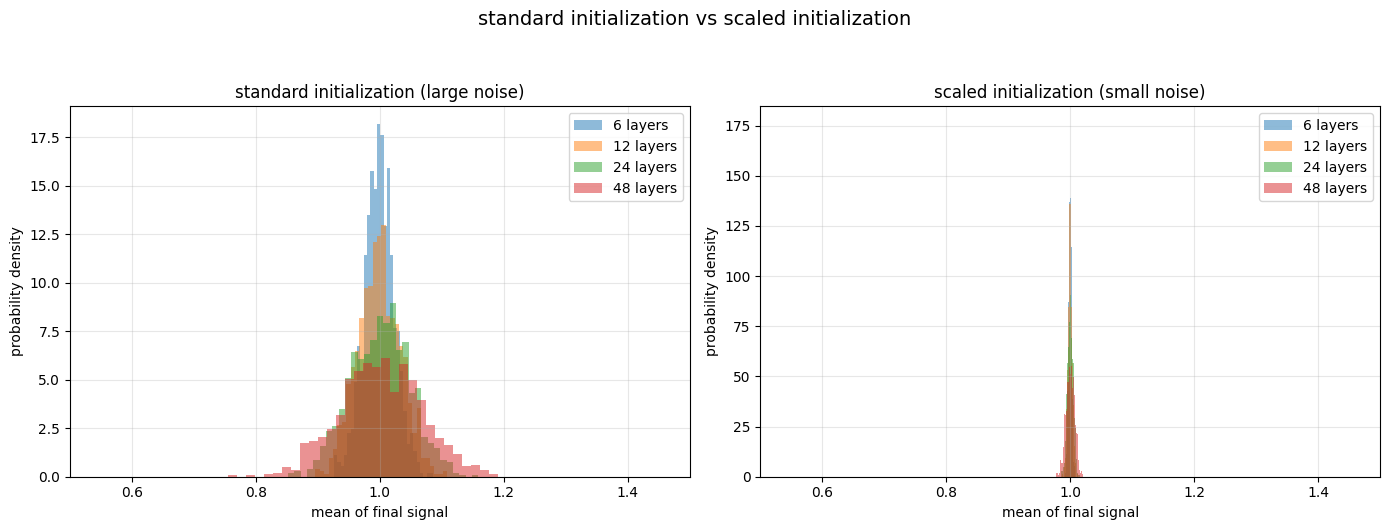

In [32]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.set_loglevel("error")


def show_real_difference():
    """show the real difference"""
    np.random.seed(42)
    
    n_layers_list = [6, 12, 24, 48]
    noise_std_large = 0.1  # 增大噪声标准差
    noise_std_small = 0.1 / np.sqrt(2 * 48)  # 缩放初始化
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax_idx, (title, use_scaling) in enumerate([
        ("standard initialization (large noise)", False),
        ("scaled initialization (small noise)", True)
    ]):
        ax = axes[ax_idx]
        
        for n_layers in n_layers_list:
            signal_means = []
            
            for _ in range(1000):  # 多次实验
                signal = np.ones(100)
                
                for layer in range(n_layers):
                    if use_scaling:
                        noise = np.random.normal(0, noise_std_small, 100)
                    else:
                        noise = np.random.normal(0, noise_std_large, 100)
                    signal = signal + noise
                
                signal_means.append(np.mean(signal))
            
            # 绘制分布
            ax.hist(signal_means, bins=30, alpha=0.5, 
                   label=f'{n_layers} layers', density=True)
        
        ax.set_xlabel('mean of final signal')
        ax.set_ylabel('probability density')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0.5, 1.5)
    
    plt.suptitle('standard initialization vs scaled initialization', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

show_real_difference()

In [36]:

# LLaMA2Model.forward 接受两个参数，tokens和targets，其中tokens是输入的张量, 应为int类型
x = torch.randint(0, 6144, (1, 50)) # [bs, seq_len]
# 实例化LLaMA2Model
model = Transformer(args=args)
# 计算model的全部参数
num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters:', num_params)

out = model(x)
print(out.logits.shape) # [batch_size, 1, vocab_size]

Number of parameters: 82594560
torch.Size([1, 1, 6144])


### 训练Tokenizer
分词方法有很多种，比如Word-based Tokenizer（无法处理OOV单词，且一些语言没有显式分词），Character-based Tokenizer(序列会很长，丢失语义), Subword-based Tokenizer(如Byte Pair Encoding, WordPiece, Unigram等，可以处理OOV，且可以保留语义，但会增加模型复杂度，需要更多计算资源),这里重点关注BPE，
#### Byte Pair Encoding(BPE)
BPE是基于统计的，通过反复合并频率最高的字符或者字符序列对来生成子词词典，简单高效，能有效处理未知词和罕见词，同时保持较低的词典大小。合并过程是自底向上的，逐步合并频率最高的字符对，直到达到预定的词典大小。
#### 训练BPE
需要安装tokenizer、datasets和transformers库

In [2]:
import random
import json
import os
from transformers import AutoTokenizer, PreTrainedTokenizerFast
from tokenizers import (
    decoders,
    models,
    pre_tokenizers,
    trainers,
    Tokenizer,
)
from tokenizers.normalizers import NFKC
from typing import Generator


def read_texts_from_jsonl(file_path: str) -> Generator[str, None, None]:
    """读取JSONL文件并安全提取文本数据"""
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            try:
                data = json.loads(line)
                if 'text' not in data:
                    raise KeyError(f"Missing 'text' field in line {line_num}")
                yield data['text']
            except json.JSONDecodeError:
                print(f"Error decoding JSON in line {line_num}")
                continue
            except KeyError as e:
                print(e)
                continue


def create_tokenizer_config(save_dir: str) -> None:
    """创建完整的tokenizer配置文件"""
    config = {
        "add_bos_token": False,
        "add_eos_token": False,
        "add_prefix_space": False,
        "bos_token": "<|im_start|>",
        "eos_token": "<|im_end|>",
        "pad_token": "<|im_end|>",
        "unk_token": "<unk>",
        "model_max_length": 1000000000000000019884624838656,
        "clean_up_tokenization_spaces": False,
        "tokenizer_class": "PreTrainedTokenizerFast",
        "chat_template": (
            "{% for message in messages %}"
            "{% if message['role'] == 'system' %}"
            "<|im_start|>system\n{{ message['content'] }}<|im_end|>\n"
            "{% elif message['role'] == 'user' %}"
            "<|im_start|>user\n{{ message['content'] }}<|im_end|>\n"
            "{% elif message['role'] == 'assistant' %}"
            "<|im_start|>assistant\n{{ message['content'] }}<|im_end|>\n"
            "{% endif %}"
            "{% endfor %}"
            "{% if add_generation_prompt %}"
            "{{ '<|im_start|>assistant\n' }}"
            "{% endif %}"
        )
    }

    # 保存主配置文件
    with open(os.path.join(save_dir, "tokenizer_config.json"), "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=4)

    # 创建special_tokens_map.json
    special_tokens_map = {
        "bos_token": "<|im_start|>",
        "eos_token": "<|im_end|>",
        "unk_token": "<unk>",
        "pad_token": "<|im_end|>",
        "additional_special_tokens": ["<s>", "</s>"]
    }
    with open(os.path.join(save_dir, "special_tokens_map.json"), "w", encoding="utf-8") as f:
        json.dump(special_tokens_map, f, ensure_ascii=False, indent=4)


def train_tokenizer(data_path: str, save_dir: str, vocab_size: int = 8192) -> None:
    """训练并保存自定义tokenizer"""
    os.makedirs(save_dir, exist_ok=True)
    
    # 初始化tokenizer
    tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
    tokenizer.normalizer = NFKC()  # 添加文本规范化
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tokenizer.decoder = decoders.ByteLevel()

    # 配置特殊token
    special_tokens = [
        "<unk>", 
        "<s>", 
        "</s>", 
        "<|im_start|>", 
        "<|im_end|>"
    ]

    # 配置训练器
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=special_tokens,
        min_frequency=2,  # 提高低频词过滤
        show_progress=True,
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet()
    )

    # 训练tokenizer
    print(f"Training tokenizer with data from {data_path}")
    texts = read_texts_from_jsonl(data_path)
    tokenizer.train_from_iterator(texts, trainer=trainer, length=os.path.getsize(data_path))

    # 验证特殊token映射
    try:
        assert tokenizer.token_to_id("<unk>") == 0
        assert tokenizer.token_to_id("<s>") == 1
        assert tokenizer.token_to_id("</s>") == 2
        assert tokenizer.token_to_id("<|im_start|>") == 3
        assert tokenizer.token_to_id("<|im_end|>") == 4
    except AssertionError as e:
        print("Special tokens mapping error:", e)
        raise

    # 保存tokenizer文件
    tokenizer.save(os.path.join(save_dir, "tokenizer.json"))
    
    # 创建配置文件
    create_tokenizer_config(save_dir)
    print(f"Tokenizer saved to {save_dir}")

In [3]:
def eval_tokenizer(tokenizer_path: str) -> None:
    """评估tokenizer功能"""
    try:
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    except Exception as e:
        print(f"Error loading tokenizer: {e}")
        return

    # 测试基本属性
    print("\n=== Tokenizer基本信息 ===")
    print(f"Vocab size: {len(tokenizer)}")
    print(f"Special tokens: {tokenizer.all_special_tokens}")
    print(f"Special token IDs: {tokenizer.all_special_ids}")

    # 测试聊天模板
    messages = [
        {"role": "system", "content": "你是一个AI助手。"},
        {"role": "user", "content": "How are you?"},
        {"role": "assistant", "content": "I'm fine, thank you. and you?"},
        {"role": "user", "content": "I'm good too."},
        {"role": "assistant", "content": "That's great to hear!"},
    ]
    
    print("\n=== 聊天模板测试 ===")
    prompt = tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        # add_generation_prompt=True
    )
    print("Generated prompt:\n", prompt, sep="")

    # 测试编码解码
    print("\n=== 编码解码测试 ===")
    encoded = tokenizer(prompt, truncation=True, max_length=256)
    decoded = tokenizer.decode(encoded["input_ids"], skip_special_tokens=False)
    print("Decoded text matches original:", decoded == prompt)

    # 测试特殊token处理
    print("\n=== 特殊token处理 ===")
    test_text = "<|im_start|>user\nHello<|im_end|>"
    encoded = tokenizer(test_text).input_ids
    decoded = tokenizer.decode(encoded)
    print(f"Original: {test_text}")
    print(f"Decoded:  {decoded}")
    print("Special tokens preserved:", decoded == test_text)

In [7]:
eval_tokenizer('../tokenizer_k')


=== Tokenizer基本信息 ===
Vocab size: 6144
Special tokens: ['<|im_start|>', '<|im_end|>', '<unk>', '<s>', '</s>']
Special token IDs: [3, 4, 0, 1, 2]

=== 聊天模板测试 ===
Generated prompt:
<|im_start|>system
你是一个AI助手。<|im_end|>
<|im_start|>user
How are you?<|im_end|>
<|im_start|>assistant
I'm fine, thank you. and you?<|im_end|>
<|im_start|>user
I'm good too.<|im_end|>
<|im_start|>assistant
That's great to hear!<|im_end|>


=== 编码解码测试 ===
Decoded text matches original: True

=== 特殊token处理 ===
Original: <|im_start|>user
Hello<|im_end|>
Decoded:  <|im_start|>user
Hello<|im_end|>
Special tokens preserved: True


### 预训练一个小模型
利用开源预训练数据集：

1.出门问问序列猴子开源数据集：来自网页、百科、博客、问答、开源代码、书籍、报刊、专利、教材、考题等多种公开可获取的数据进行汇总清洗之后而形成的大语言模型预训练语料。总量大概在 10B Token。

2.BelleGroup：350万条中文对话数据集，包含了人机对话、人人对话、人物对话等多种对话数据，可以用于训练对话生成模型。

In [ ]:


# 下载预训练数据集
# os.system("modelscope download --dataset ddzhu123/seq-monkey mobvoi_seq_monkey_general_open_corpus.jsonl.tar.bz2 --local_dir ./data")
# 解压预训练数据集
# os.system("tar -xvf ./data/mobvoi_seq_monkey_general_open_corpus.jsonl.tar.bz2")

In [ ]:
# 下载SFT数据集
# os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
# os.system(f'hf download --repo-type dataset BelleGroup/train_3.5M_CN --local-dir ./data/BelleGroup')

Fetching 3 files:  67%|██████▋   | 2/3 [00:00<00:00,  3.02it/s]

/home/hzh/program/llm/note/data/BelleGroup


Fetching 3 files: 100%|██████████| 3/3 [24:49<00:00, 496.60s/it]


0

In [ ]:
from tqdm import tqdm
# 1 处理预训练数据
def split_text(text, chunk_size=512):
    """将文本按指定长度切分成块"""
    return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

input_file = './data/mobvoi_seq_monkey_general_open_corpus.jsonl'

with open('../data/seq_monkey_datawhale.jsonl', 'a', encoding='utf-8') as pretrain:
    with open(input_file, 'r', encoding='utf-8') as f:
        data = f.readlines()
        for line in tqdm(data, desc=f"Processing lines in {input_file}", leave=False):  # 添加行级别的进度条
            line = json.loads(line)
            text = line['text']
            chunks = split_text(text)
            for chunk in chunks:
                pretrain.write(json.dumps({'text': chunk}, ensure_ascii=False) + '\n')


In [ ]:
from tqdm import tqdm
import json
# 2 处理SFT数据

def convert_message(data):
    """
    将原始数据转换为标准格式
    """
    message = [
        {"role": "system", "content": "你是一个AI助手"},
    ]
    for item in data:
        if item['from'] == 'human':
            message.append({'role': 'user', 'content': item['value']})
        elif item['from'] == 'assistant':
            message.append({'role': 'assistant', 'content': item['value']})
    return message

with open('../data/BelleGroup_sft.jsonl', 'a', encoding='utf-8') as sft:
    with open('./data/BelleGroup/train_3.5M_CN.json', 'r', encoding='utf-8') as f:
        data = f.readlines()
        for item in tqdm(data, desc="Processing", unit="lines"):
            item = json.loads(item)
            message = convert_message(item['conversations'])
            sft.write(json.dumps(message, ensure_ascii=False) + '\n')

Processing: 100%|██████████| 3606402/3606402 [02:58<00:00, 20239.34lines/s]


#### 使用出门问问序列猴子数据集训练BPE
训练过程

1.Pre-processing sequences
- 读取并准备所有训练数据
- 应用NFKC规范化（统一字符表示）
- 将文本拆分成字节或字符
- 为BPE算法准备输入序列
处理时间大概在半小时，序列长度近40M

2.Tokenize words(即BPE训练)
- 统计字节对频率
- 合并最高频字节对直到达到vocab size
- 构建最终词汇表


### Dataset
#### PretrainDataset
需要先处理文本数据为模型能理解的Token，自定义一个PretrainDataset类，用来加载已处理好的数据集

In [37]:
from torch.utils.data import Dataset

class PretrainDataset(Dataset):
    def __init__(self, data_path, tokenizer, max_length=512):
        super().__init__()
        self.data_path = data_path
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.padding = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
        # 预计算每行的起始字节偏移量
        self._offsets = []
        with open(data_path, 'rb') as f:
            self._offsets.append(0)
            while f.readline():
                self._offsets.append(f.tell())
        self._total_lines = len(self._offsets) - 1  # 最后一个 tell() 是 EOF

    def __len__(self):
        return self._total_lines

    def __getitem__(self, index: int):
        with open(self.data_path, 'rb') as f:
            f.seek(self._offsets[index])
            line = f.readline().decode('utf-8')
        sample = json.loads(line)
        text = f"{self.tokenizer.bos_token}{sample['text']}"
        input_id = self.tokenizer(text).data['input_ids'][:self.max_length]
        text_len = len(input_id)
        # 没满最大长度的剩余部分
        padding_len = self.max_length - text_len
        input_id = input_id + [self.padding] * padding_len
        # 0表示不计算损失
        loss_mask = [1] * text_len + [0] * padding_len

        input_id = np.array(input_id)
        X = np.array(input_id[:-1]).astype(np.int64)
        Y = np.array(input_id[1:]).astype(np.int64)
        loss_mask = np.array(loss_mask[1:]).astype(np.int64)
        return torch.from_numpy(X), torch.from_numpy(Y), torch.from_numpy(loss_mask)

#### SFT Dataset
多轮对话数据集，我们的目标是让模型学会如何进行多轮对话。在这个阶段我们的输入是上一轮的对话内容，输出是当前轮的对话内容。

关于loss的计算，这里使用generate_loss_mask 函数来生成 loss_mask。这个函数主要是用来生成 loss_mask，其中 loss_mask 的生成规则是：当遇到 |<im_start|>assistant\n 时，就开始计算损失，直到遇到 |<im_end|> 为止。

In [38]:
class SFTDataset(Dataset):
    def __init__(self, data_path, tokenizer, max_length=512):
        super().__init__()
        self.data_path = data_path
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.padding = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
        self._offsets = []
        with open(data_path, 'rb') as f:
            self._offsets.append(0)
            while f.readline():
                self._offsets.append(f.tell())
        self._total_lines = len(self._offsets) - 1 

    def __len__(self):
        return self._total_lines

    def generate_loss_mask(self, input_ids):
        # 生成 loss mask, 0 表示不计算损失, 1 表示计算损失
        mask = [0] * len(input_ids)
        a_sequence = self.tokenizer("<|im_start|>assistant\n")['input_ids']  # <|im_start|>assistant\n
        a_length = len(a_sequence)
        n = len(input_ids)
        i = 0
        
        while i <= n - a_length:
            # 检查当前位置是否匹配目标子序列
            match = True
            for k in range(a_length):
                if input_ids[i + k] != a_sequence[k]:
                    match = False
                    break
            if match:
                # 从子序列结束的位置开始查找第一个 4 (eos_token_id)
                j = None
                for idx in range(i + a_length, n):
                    if input_ids[idx] == self.tokenizer.eos_token_id:
                        j = idx
                        break
                if j is not None:
                    start = i + a_length
                    end = j  # 结束位置设为j（包含4）
                    # 标记区间为1（包括start到end）
                    if start <= end:
                        for pos in range(start, end + 1):
                            if pos < len(mask):
                                mask[pos] = 1
                # 跳过当前子序列，避免重叠匹配
                i += a_length
            else:
                i += 1
        return mask

    def __getitem__(self, index: int):
        with open(self.data_path, 'rb') as f:
            f.seek(self._offsets[index])
            line = f.readline().decode('utf-8')
        sample = json.loads(line)
        text = self.tokenizer.apply_chat_template(sample, tokenize=False, add_generation_prompt=False)
        input_id = self.tokenizer(text).data['input_ids'][:self.max_length]
        text_len = len(input_id)
        # 没满最大长度的剩余部分
        padding_len = self.max_length - text_len
        input_id = input_id + [self.padding] * padding_len
        # 0表示不计算损失
        loss_mask = self.generate_loss_mask(input_id)

        input_id = np.array(input_id)
        X = np.array(input_id[:-1]).astype(np.int64)
        Y = np.array(input_id[1:]).astype(np.int64)
        loss_mask = np.array(loss_mask[1:]).astype(np.int64)
        return torch.from_numpy(X), torch.from_numpy(Y), torch.from_numpy(loss_mask)

### Pretrain
使用前面的LLama2模型